In [34]:
import pandas as pd
import numpy as np
import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import cufflinks as cf
import plotly.graph_objects as go

In [35]:
close_price_df = pd.read_csv('Sample_Data/nasdaq_top_tech.csv')
close_price_df

,Date,AAPL,ADBE,AMZN,GOOGL,INTC,META,MSFT,NFLX,NVDA,TSLA
0,2013-01-02,16.7057,38.34,12.8655,18.0546,15.2893,27.9159,22.4518,13.1443,0.2935,2.3573
1,2013-01-03,16.4948,37.75,12.9240,18.0651,15.2464,27.6866,22.1510,13.7986,0.2938,2.3180
2,2013-01-04,16.0354,38.13,12.9575,18.4221,15.1320,28.6737,21.7365,13.7114,0.3035,2.2933
3,2013-01-07,15.9411,37.94,13.4230,18.3417,15.1963,29.3317,21.6958,14.1714,0.2947,2.2893
4,2013-01-08,15.9840,38.14,13.3190,18.3055,15.0819,28.9728,21.5820,13.8800,0.2882,2.2453
...,...,...,...,...,...,...,...,...,...,...,...
2978,2024-10-31,225.9100,478.08,186.4000,171.1100,21.5200,567.5800,406.3500,756.0300,132.7600,249.8500
2979,2024-11-01,222.9100,482.80,197.9300,171.2900,23.2000,567.1600,410.3700,756.1000,135.4000,248.9800
2980,2024-11-04,222.0100,481.35,195.7800,169.2400,22.5200,560.6800,408.4600,755.5100,136.0500,242.8400
2981,2024-11-05,223.4500,486.42,199.5000,169.7400,23.3200,572.4300,411.4600,763.9100,139.9100,251.4400


In [36]:
daily_return_df = close_price_df.iloc[:,1:].pct_change()*100
daily_return_df.replace(np.nan,0,inplace = True)
daily_return_df

,AAPL,ADBE,AMZN,GOOGL,INTC,META,MSFT,NFLX,NVDA,TSLA
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,-1.262443,-1.538863,0.454704,0.058157,-0.280588,-0.821396,-1.339759,4.977823,0.102215,-1.667162
2,-2.785120,1.006623,0.259208,1.976186,-0.750341,3.565263,-1.871247,-0.631948,3.301566,-1.065574
3,-0.588074,-0.498295,3.592514,-0.436432,0.424927,2.294786,-0.187243,3.354873,-2.899506,-0.174421
4,0.269116,0.527148,-0.774790,-0.197364,-0.752815,-1.223591,-0.524525,-2.056254,-2.205633,-1.921985
...,...,...,...,...,...,...,...,...,...,...
2978,-1.820947,-1.767075,-3.284387,-1.920211,-3.497758,-4.092599,-6.052759,0.303818,-4.722262,-2.989711
2979,-1.327962,0.987282,6.185622,0.105195,7.806691,-0.073998,0.989295,0.009259,1.988551,-0.348209
2980,-0.403750,-0.300331,-1.086243,-1.196801,-2.931034,-1.142535,-0.465434,-0.078032,0.480059,-2.466062
2981,0.648619,1.053288,1.900092,0.295438,3.552398,2.095670,0.734466,1.111832,2.837192,3.541426


In [37]:
daily_return_df.insert(0,"Date",close_price_df['Date'])
daily_return_df

,Date,AAPL,ADBE,AMZN,GOOGL,INTC,META,MSFT,NFLX,NVDA,TSLA
0,2013-01-02,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,2013-01-03,-1.262443,-1.538863,0.454704,0.058157,-0.280588,-0.821396,-1.339759,4.977823,0.102215,-1.667162
2,2013-01-04,-2.785120,1.006623,0.259208,1.976186,-0.750341,3.565263,-1.871247,-0.631948,3.301566,-1.065574
3,2013-01-07,-0.588074,-0.498295,3.592514,-0.436432,0.424927,2.294786,-0.187243,3.354873,-2.899506,-0.174421
4,2013-01-08,0.269116,0.527148,-0.774790,-0.197364,-0.752815,-1.223591,-0.524525,-2.056254,-2.205633,-1.921985
...,...,...,...,...,...,...,...,...,...,...,...
2978,2024-10-31,-1.820947,-1.767075,-3.284387,-1.920211,-3.497758,-4.092599,-6.052759,0.303818,-4.722262,-2.989711
2979,2024-11-01,-1.327962,0.987282,6.185622,0.105195,7.806691,-0.073998,0.989295,0.009259,1.988551,-0.348209
2980,2024-11-04,-0.403750,-0.300331,-1.086243,-1.196801,-2.931034,-1.142535,-0.465434,-0.078032,0.480059,-2.466062
2981,2024-11-05,0.648619,1.053288,1.900092,0.295438,3.552398,2.095670,0.734466,1.111832,2.837192,3.541426


In [38]:
def plot_financial_data(df,title):
    fig = px.line (title=title)
    for i in df.columns[1:]:
        fig.add_scatter(x = df['Date'],y=df[i],name =i)
        fig.update_traces(line_width = 5)
        fig.update_layout({'plot_bgcolor':"white"})
    fig.show()

In [39]:
plot_financial_data(close_price_df, 'Adjusted Closing Prices [$]')

In [40]:
plot_financial_data(daily_return_df,'Percentage Daily Returns [%]')

In [41]:
fig = px.histogram(daily_return_df.drop(columns=['Date']))
fig.update_layout({'plot_bgcolor':"white"})

<Axes: >

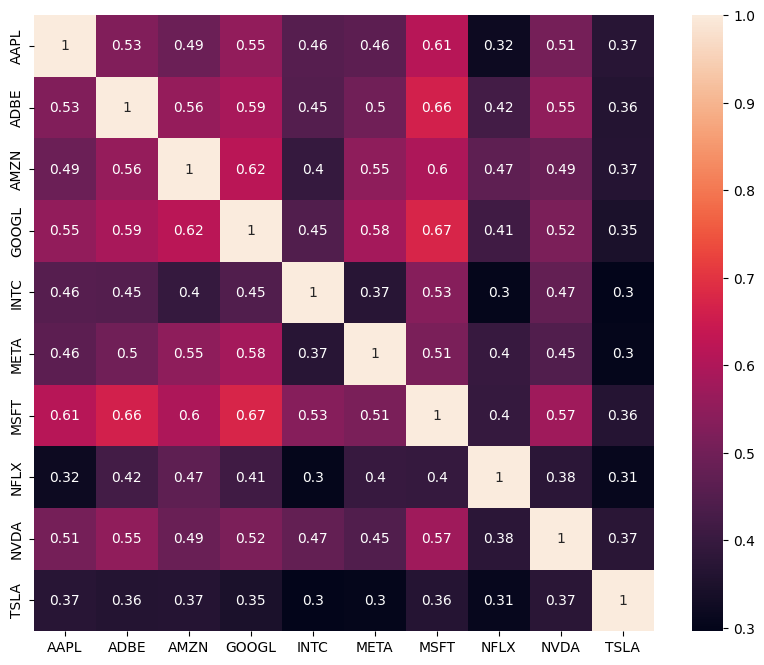

In [42]:
plt.figure(figsize = (10,8))
sns.heatmap(daily_return_df.drop(columns = ['Date']).corr(),annot= True)

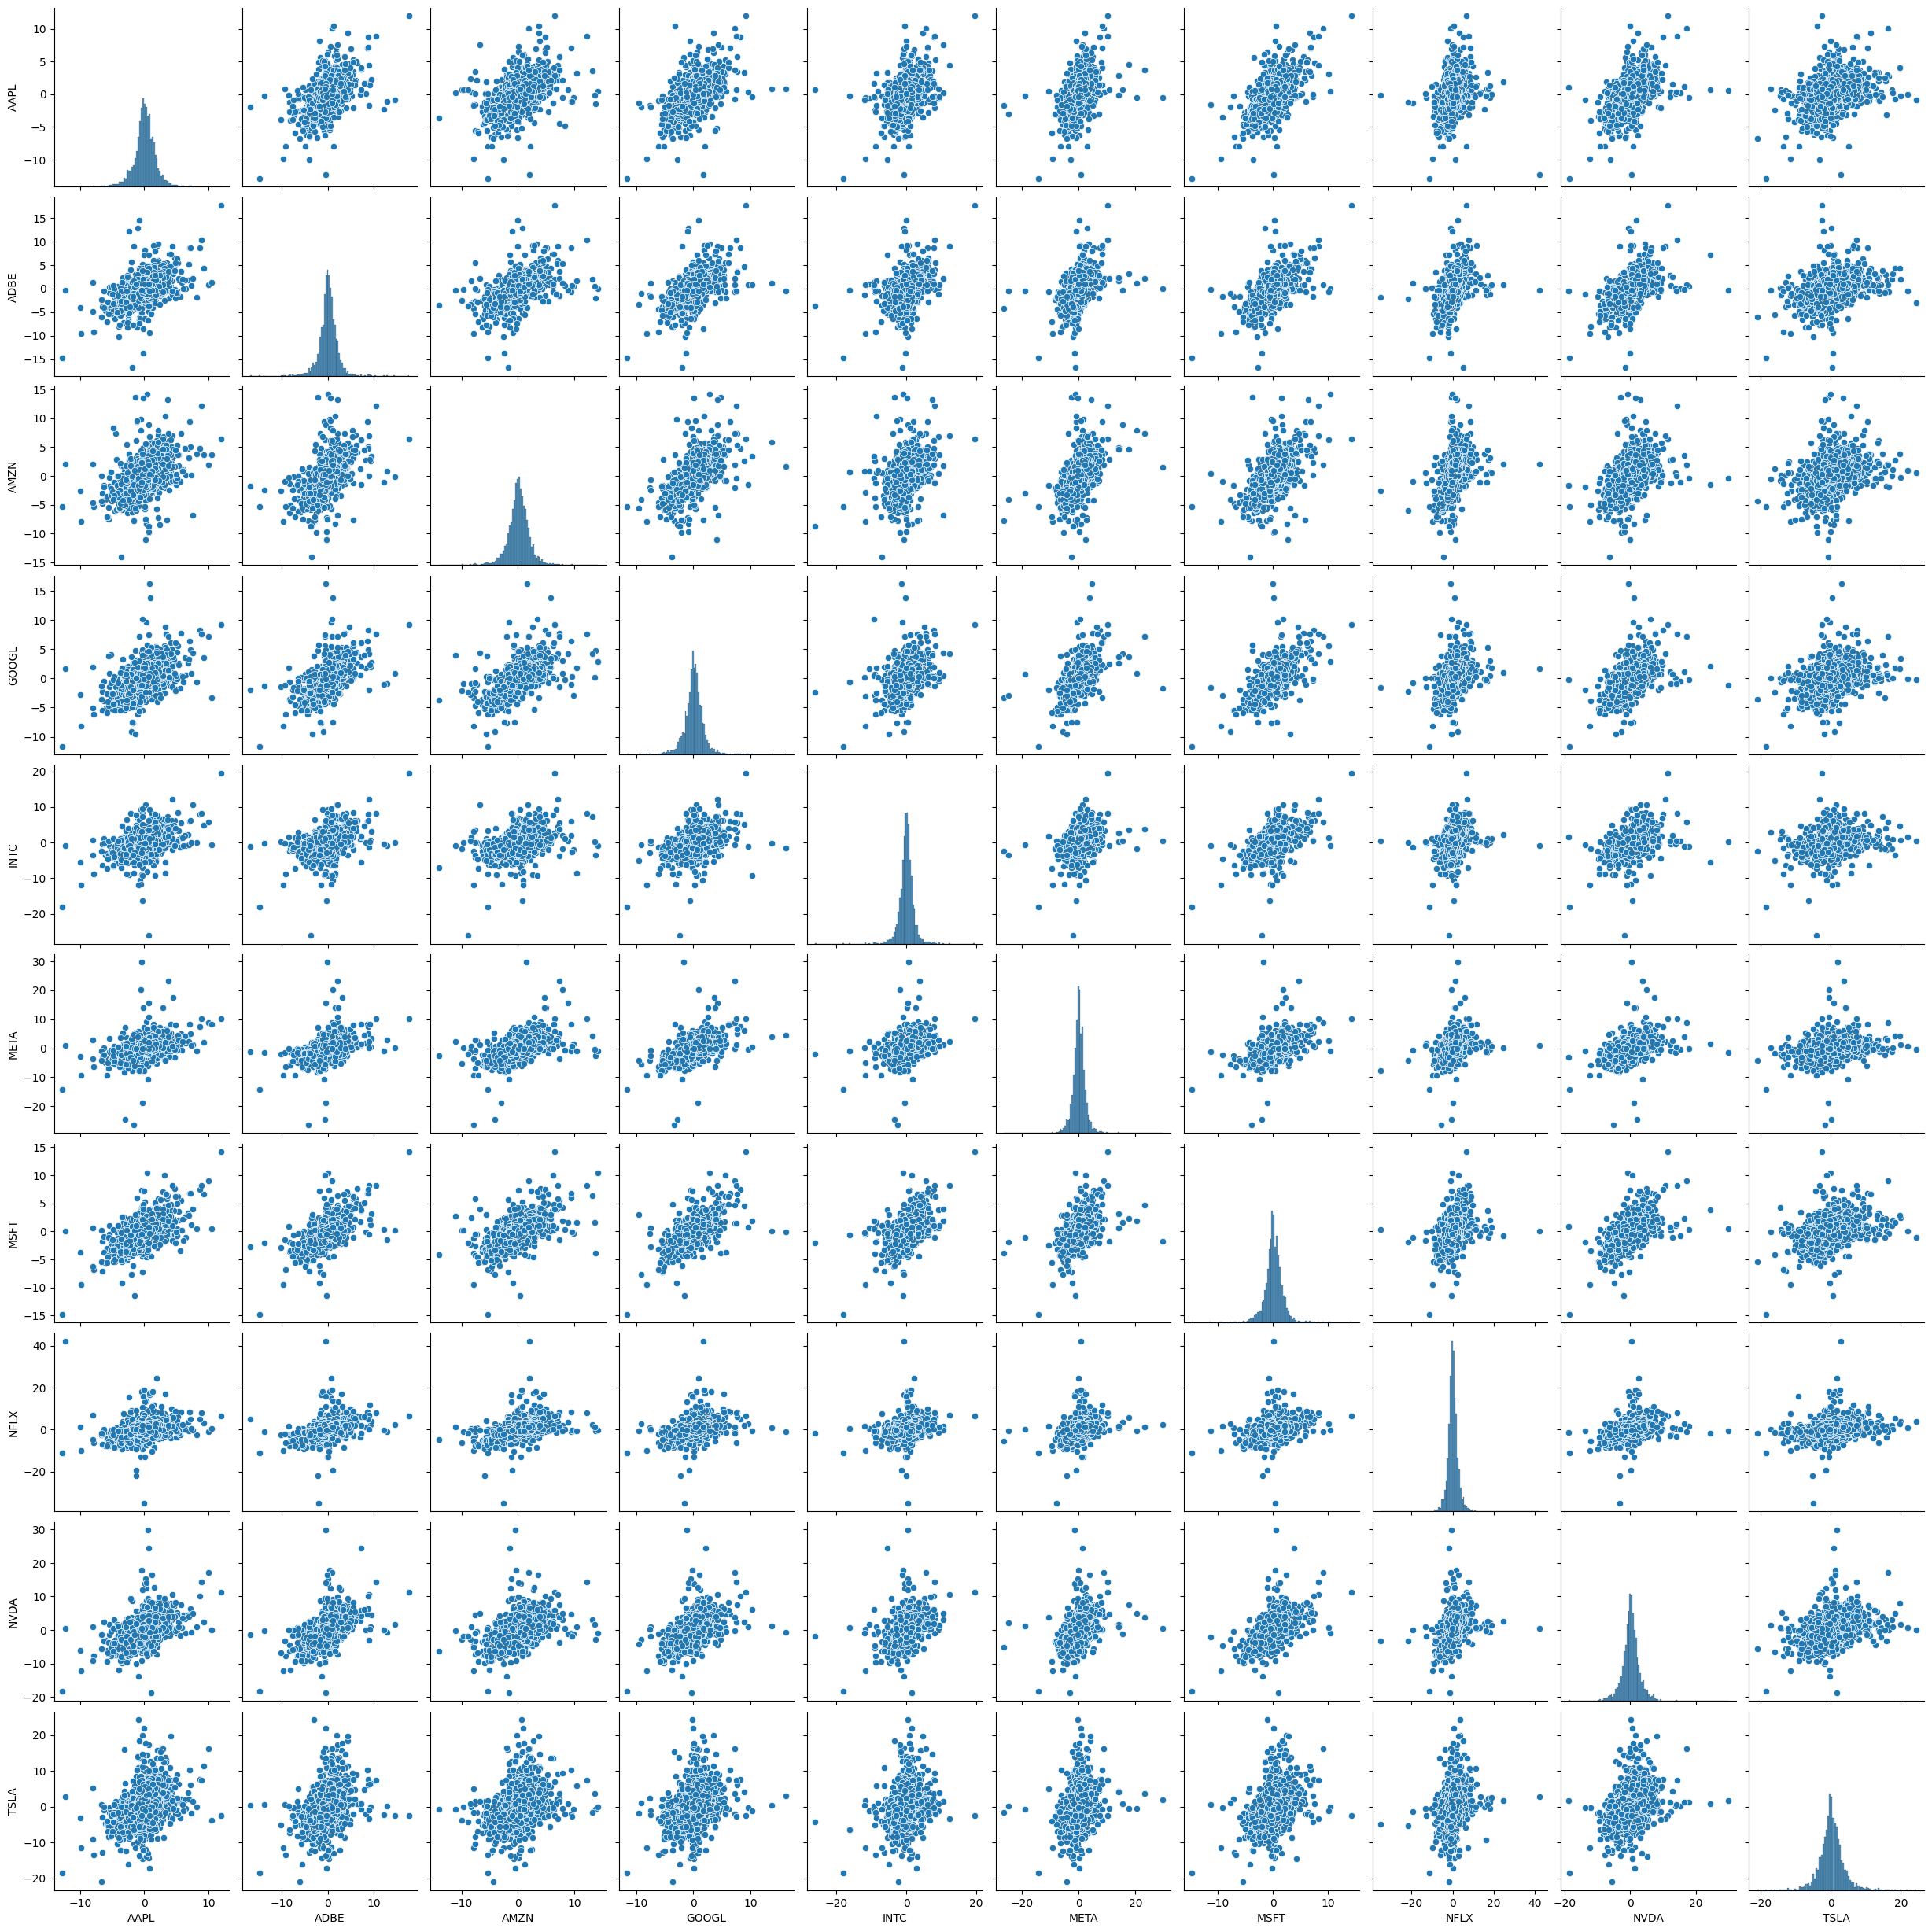

In [43]:
sns.pairplot(daily_return_df)

In [44]:
def price_scaling(raw_prices_df):
    scaled_prices_df = raw_prices_df.copy()
    for i in raw_prices_df.columns[1:]:
        scaled_prices_df[i] = raw_prices_df[i]/raw_prices_df[i][0]
    return scaled_prices_df
price_scaling(close_price_df)


,Date,AAPL,ADBE,AMZN,GOOGL,INTC,META,MSFT,NFLX,NVDA,TSLA
0,2013-01-02,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
1,2013-01-03,0.987376,0.984611,1.004547,1.000582,0.997194,0.991786,0.986602,1.049778,1.001022,0.983328
2,2013-01-04,0.959876,0.994523,1.007151,1.020355,0.989712,1.027146,0.968141,1.043144,1.034072,0.972850
3,2013-01-07,0.954231,0.989567,1.043333,1.015902,0.993917,1.050717,0.966328,1.078140,1.004089,0.971153
4,2013-01-08,0.956799,0.994784,1.035249,1.013897,0.986435,1.037860,0.961259,1.055971,0.981942,0.952488
...,...,...,...,...,...,...,...,...,...,...,...
2978,2024-10-31,13.522929,12.469484,14.488360,9.477363,1.407520,20.331782,18.098772,57.517707,452.333901,105.989904
2979,2024-11-01,13.343350,12.592593,15.384556,9.487333,1.517401,20.316737,18.277822,57.523033,461.328790,105.620837
2980,2024-11-04,13.289476,12.554773,15.217442,9.373788,1.472926,20.084611,18.192751,57.478146,463.543441,103.016163
2981,2024-11-05,13.375674,12.687011,15.506587,9.401482,1.525250,20.505518,18.326370,58.117207,476.695060,106.664404


In [45]:
import random

def generate_portfolio_weights(n):
    weights = []
    for i in range(n):
        weights.append(random.random())
    weights = weights/np.sum(weights)
    return weights

# Run multiple times to generate different ouputs
weights = generate_portfolio_weights(4)
print( weights)

[0.34263675 0.36085434 0.0477037  0.24880521]


In [46]:
portfolio_df = close_price_df.copy()
scaled_df = price_scaling(portfolio_df)
scaled_df

,Date,AAPL,ADBE,AMZN,GOOGL,INTC,META,MSFT,NFLX,NVDA,TSLA
0,2013-01-02,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
1,2013-01-03,0.987376,0.984611,1.004547,1.000582,0.997194,0.991786,0.986602,1.049778,1.001022,0.983328
2,2013-01-04,0.959876,0.994523,1.007151,1.020355,0.989712,1.027146,0.968141,1.043144,1.034072,0.972850
3,2013-01-07,0.954231,0.989567,1.043333,1.015902,0.993917,1.050717,0.966328,1.078140,1.004089,0.971153
4,2013-01-08,0.956799,0.994784,1.035249,1.013897,0.986435,1.037860,0.961259,1.055971,0.981942,0.952488
...,...,...,...,...,...,...,...,...,...,...,...
2978,2024-10-31,13.522929,12.469484,14.488360,9.477363,1.407520,20.331782,18.098772,57.517707,452.333901,105.989904
2979,2024-11-01,13.343350,12.592593,15.384556,9.487333,1.517401,20.316737,18.277822,57.523033,461.328790,105.620837
2980,2024-11-04,13.289476,12.554773,15.217442,9.373788,1.472926,20.084611,18.192751,57.478146,463.543441,103.016163
2981,2024-11-05,13.375674,12.687011,15.506587,9.401482,1.525250,20.505518,18.326370,58.117207,476.695060,106.664404


In [47]:
weights = [0.032266, 0.094461, 0.117917, 0.132624, 0.145942, 0.128299, 0.10009, 0.007403, 0.088581, 0.152417]
weights

[0.032266,
 0.094461,
 0.117917,
 0.132624,
 0.145942,
 0.128299,
 0.10009,
 0.007403,
 0.088581,
 0.152417]

In [48]:
initial_investment = 1000000
for i, stock in enumerate(scaled_df.columns[1:]):
    portfolio_df[stock] = weights[i] * scaled_df[stock]  * initial_investment
portfolio_df.round(1)

,Date,AAPL,ADBE,AMZN,GOOGL,INTC,META,MSFT,NFLX,NVDA,TSLA
0,2013-01-02,32266.0,94461.0,117917.0,132624.0,145942.0,128299.0,100090.0,7403.0,88581.0,152417.0
1,2013-01-03,31858.7,93007.4,118453.2,132701.1,145532.5,127245.2,98749.0,7771.5,88671.5,149876.0
2,2013-01-04,30971.4,93943.6,118760.2,135323.6,144440.5,131781.8,96901.2,7722.4,91599.1,148278.9
3,2013-01-07,30789.2,93475.5,123026.7,134733.0,145054.3,134805.9,96719.8,7981.5,88943.2,148020.3
4,2013-01-08,30872.1,93968.2,122073.5,134467.0,143962.3,133156.4,96212.4,7817.4,86981.4,145175.4
...,...,...,...,...,...,...,...,...,...,...,...
2978,2024-10-31,436330.8,1177879.9,1708424.0,1256925.8,205416.3,2608547.3,1811506.0,425803.6,40068189.3,16154663.2
2979,2024-11-01,430536.5,1189508.9,1814100.6,1258248.0,221452.5,2606617.0,1829427.2,425843.0,40864965.6,16098411.2
2980,2024-11-04,428798.2,1185936.4,1794395.1,1243189.3,214961.7,2576835.5,1820912.4,425510.7,41061141.6,15701414.4
2981,2024-11-05,431579.5,1198427.7,1828490.3,1246862.2,222598.0,2630837.5,1834286.4,430241.7,42226125.1,16257468.5


In [49]:
# Assume that we have $1,000,000 that we would like to invest in one or more of the selected stocks
# Let's create a function that receives the following arguments: 
      # (1) Stocks closing prices
      # (2) Random weights 
      # (3) Initial investment amount
# The function will return a DataFrame that contains the following:
      # (1) Daily value (position) of each individual stock over the specified time period
      # (2) Total daily value of the portfolio 
      # (3) Percentage daily return 

def asset_allocation(df, weights, initial_investment):
    portfolio_df = df.copy()

    # Scale stock prices using the "price_scaling" function that we defined earlier (Make them all start at 1)
    scaled_df = price_scaling(df)
  
    for i, stock in enumerate(scaled_df.columns[1:]):
        portfolio_df[stock] = scaled_df[stock] * weights[i] * initial_investment

    # Sum up all values and place the result in a new column titled "portfolio value [$]" 
    # Note that we excluded the date column from this calculation
    portfolio_df['Portfolio Value [$]'] = portfolio_df[portfolio_df != 'Date'].sum(axis = 1, numeric_only = True)
            
    # Calculate the portfolio percentage daily return and replace NaNs with zeros
    portfolio_df['Portfolio Daily Return [%]'] = portfolio_df['Portfolio Value [$]'].pct_change(1) * 100 
    portfolio_df.replace(np.nan, 0, inplace = True)
    
    return portfolio_df

In [50]:

n = len(close_price_df.columns)-1

print('Number of stocks under consideration = {}'.format(n))
weights = generate_portfolio_weights(n).round(6)
print('Portfolio weights = {}'.format(weights))

# Let's test out the "asset_allocation" function
portfolio_df = asset_allocation(close_price_df, weights, 1000000)
portfolio_df.round(2)

Number of stocks under consideration = 10
Portfolio weights = [0.174787 0.032758 0.109018 0.186718 0.014068 0.023912 0.065405 0.082043
 0.172485 0.138808]


,Date,AAPL,ADBE,AMZN,GOOGL,INTC,META,MSFT,NFLX,NVDA,TSLA,Portfolio Value [$],Portfolio Daily Return [%]
0,2013-01-02,174787.00,32758.00,109018.00,186718.00,14068.00,23912.00,65405.00,82043.00,172485.00,138808.00,1.000002e+06,0.00
1,2013-01-03,172580.41,32253.90,109513.71,186826.59,14028.53,23715.59,64528.73,86126.96,172661.30,136493.85,9.987296e+05,-0.13
2,2013-01-04,167773.84,32578.57,109797.58,190518.63,13923.27,24561.11,63321.24,85582.68,178361.83,135039.40,1.001458e+06,0.27
3,2013-01-07,166787.21,32416.24,113742.07,189687.15,13982.43,25124.74,63202.67,88453.87,173190.22,134803.87,1.001390e+06,-0.01
4,2013-01-08,167236.06,32587.12,112860.81,189312.77,13877.17,24817.31,62871.16,86635.03,169370.28,132212.96,9.917807e+05,-0.96
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2978,2024-10-31,2363632.24,408475.34,1579492.07,1769594.29,19801.00,486173.58,1183750.16,4718925.26,78020812.95,14712246.55,1.052629e+08,-4.14
2979,2024-11-01,2332244.09,412508.15,1677193.48,1771455.82,21346.80,485813.82,1195460.94,4719362.18,79572296.42,14661017.20,1.068487e+08,1.51
2980,2024-11-04,2322827.65,411269.26,1658975.09,1750255.02,20721.12,480263.22,1189896.86,4715679.57,79954290.46,14299467.49,1.068036e+08,-0.04
2981,2024-11-05,2337893.96,415601.10,1690497.14,1755425.95,21457.21,490327.96,1198636.25,4768109.99,82222747.36,14805872.62,1.097066e+08,2.72


In [51]:
plot_financial_data(portfolio_df[['Date','Portfolio Daily Return [%]']],'Portfolio Percentage Daily Return [%]')

plot_financial_data(portfolio_df.drop(['Portfolio Value [$]', 'Portfolio Daily Return [%]'], axis = 1), 'Portfolio positions [$]')

plot_financial_data(portfolio_df[['Date','Portfolio Value [$]']],'Total Porfolio Value [$]')

In [52]:
def simulation_engine(weights, initial_investment):
    # Perform asset allocation using the random weights (sent as arguments to the function)
    portfolio_df = asset_allocation(close_price_df, weights, initial_investment)
    # Calculate the return on the investment 
    # Return on investment is calculated using the last final value of the portfolio compared to its initial value
    return_on_investment = ((portfolio_df['Portfolio Value [$]'][-1:] - 
                             portfolio_df['Portfolio Value [$]'][0])/ 
                             portfolio_df['Portfolio Value [$]'][0]) * 100
     # Daily change of every stock in the portfolio (Note that we dropped the date, portfolio daily worth and daily % returns) 
    portfolio_daily_return_df = portfolio_df.drop(columns = ['Date', 'Portfolio Value [$]', 'Portfolio Daily Return [%]'])
    portfolio_daily_return_df = portfolio_daily_return_df.pct_change(1) 
    # Portfolio Expected Return formula
    expected_portfolio_return = np.sum(weights * portfolio_daily_return_df.mean() ) * 252
    # Portfolio volatility (risk) formula
    # The risk of an asset is measured using the standard deviation which indicates the dispertion away from the mean
    # The risk of a portfolio is not a simple sum of the risks of the individual assets within the portfolio
    # Portfolio risk must consider correlations between assets within the portfolio which is indicated by the covariance 
    # The covariance determines the relationship between the movements of two random variables
    # When two stocks move together, they have a positive covariance when they move inversely, the have a negative covariance 
    covariance = portfolio_daily_return_df.cov() * 252 
    expected_volatility = np.sqrt(np.dot(weights.T, np.dot(covariance, weights)))
    rf = 0.01 # Try to set the risk free rate of return
    # Calculate Sharpe ratio
    sharpe_ratio = (expected_portfolio_return - rf)/expected_volatility
    return expected_portfolio_return, expected_volatility, sharpe_ratio, portfolio_df['Portfolio Value [$]'][-1:].values[0], return_on_investment.values[0]


In [53]:
# Assume equal weights allocation
weights = np.ones(10) * 0.1
weights

array([0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1])

In [54]:
initial_investment = 1000000
portfolio_metrics = simulation_engine(weights, initial_investment)

print('Expected Portfolio Annual Return = {:.2f}%'.format(portfolio_metrics[0] * 100))
print('Portfolio Standard Deviation (Volatility) = {:.2f}%'.format(portfolio_metrics[1] * 100))
print('Sharpe Ratio = {:.2f}'.format(portfolio_metrics[2]))
print('Portfolio Final Value = ${:.2f}'.format(portfolio_metrics[3]))
print('Return on Investment = {:.2f}%'.format(portfolio_metrics[4]))

Expected Portfolio Annual Return = 34.01%
Portfolio Standard Deviation (Volatility) = 25.89%
Sharpe Ratio = 1.28
Portfolio Final Value = $77108886.05
Return on Investment = 7610.89%


In [55]:
# Run Monte Carlo Simulations

In [56]:
sim_runs = 10000
initial_investment = 1000000

weights_runs = np.zeros((sim_runs,n))

sharpe_ratio_runs = np.zeros(sim_runs)

expected_portfolio_returns_run = np.zeros(sim_runs)

volatility_runs = np.zeros(sim_runs)

return_on_investment_runs = np.zeros(sim_runs)

final_value_runs = np.zeros(sim_runs)

for i in range (sim_runs):
    weights = generate_portfolio_weights(n)
    weights_runs[i,:] = weights
    expected_portfolio_returns_run[i],volatility_runs[i],sharpe_ratio_runs[i],final_value_runs[i],return_on_investment_runs[i] = simulation_engine(weights,initial_investment)

    print("Simulation Run = {}".format(i))
    print("weights = {},Final Value = ${:.2f},Sharpe Ratio = {:2.2f}".format(weights_runs[i].round(3),final_value_runs[i],sharpe_ratio_runs[i]))
    print('\n')

Simulation Run = 0
weights = [0.09  0.061 0.172 0.015 0.141 0.167 0.029 0.199 0.108 0.019],Final Value = $76574403.99,Sharpe Ratio = 1.21


Simulation Run = 1
weights = [0.133 0.084 0.139 0.146 0.036 0.145 0.059 0.108 0.142 0.008],Final Value = $88326556.93,Sharpe Ratio = 1.27


Simulation Run = 2
weights = [0.065 0.216 0.207 0.131 0.001 0.096 0.084 0.082 0.007 0.111],Final Value = $33649744.94,Sharpe Ratio = 1.21


Simulation Run = 3
weights = [0.075 0.22  0.109 0.057 0.035 0.    0.068 0.034 0.192 0.209],Final Value = $130581575.67,Sharpe Ratio = 1.34


Simulation Run = 4
weights = [0.024 0.166 0.144 0.012 0.107 0.081 0.062 0.079 0.16  0.167],Final Value = $112210446.14,Sharpe Ratio = 1.31


Simulation Run = 5
weights = [0.188 0.002 0.129 0.07  0.058 0.094 0.101 0.174 0.017 0.168],Final Value = $48353867.08,Sharpe Ratio = 1.28


Simulation Run = 6
weights = [0.057 0.003 0.015 0.156 0.051 0.199 0.04  0.084 0.191 0.203],Final Value = $132166299.63,Sharpe Ratio = 1.37


Simulation Run = 

In [57]:
#Return the minimum Sharpe ratio
sharpe_ratio_runs.min().round(4)


np.float64(0.9391)

In [58]:
weights_runs[sharpe_ratio_runs.argmax(),:]

array([0.09603304, 0.12304311, 0.01777834, 0.0198708 , 0.00954497,
       0.0536609 , 0.02729055, 0.15629172, 0.29806987, 0.19841671])

In [59]:
optimal_portfolio_return, optimal_volatility, optimal_sharpe_ratio, highest_final_value, optimal_return_on_investment = simulation_engine(weights_runs[sharpe_ratio_runs.argmax(), :], initial_investment)
print('Best Portfolio Metrics Based on {} Monte Carlo Simulation Runs:'.format(sim_runs))
print(' - Portfolio Expected Annual Return = {:.2f}%'.format(optimal_portfolio_return*100))
print(' - Portfolio Standard Deviation (Volatility)= {:.2f}%'.format(optimal_volatility*100))
print(' - Sharpe Ratio = {:.2f}'.format(optimal_sharpe_ratio))
print(' - Final Value = ${:.2f}'.format(highest_final_value))
print(' - Return on Investment = {:.2f}%'.format(optimal_return_on_investment))

Best Portfolio Metrics Based on 10000 Monte Carlo Simulation Runs:
 - Portfolio Expected Annual Return = 46.42%
 - Portfolio Standard Deviation (Volatility)= 31.26%
 - Sharpe Ratio = 1.45
 - Final Value = $186447010.73
 - Return on Investment = 18544.70%


In [60]:
sim_out_df = pd.DataFrame({'Volatility': volatility_runs.tolist(), 'Portfolio_Return': expected_portfolio_returns_run.tolist(), 'Sharpe_Ratio': sharpe_ratio_runs.tolist() })
sim_out_df

,Volatility,Portfolio_Return,Sharpe_Ratio
0,0.269415,0.336978,1.213658
1,0.259750,0.340542,1.272537
2,0.260127,0.324274,1.208157
3,0.291045,0.400822,1.342825
4,0.282344,0.379858,1.309956
...,...,...,...
9995,0.256298,0.326175,1.233624
9996,0.263799,0.349345,1.286379
9997,0.272277,0.368080,1.315132
9998,0.257859,0.333425,1.254272


In [61]:
fig_1 = px.scatter(sim_out_df,x ='Volatility',y = 'Portfolio_Return',color = 'Sharpe_Ratio',size = 'Sharpe_Ratio', hover_data = ['Sharpe_Ratio'])
fig_1.update_layout({'plot_bgcolor':"white"})
fig_1.show()

In [62]:
# Let's highlight the point with the highest Sharpe ratio
fig = px.scatter(sim_out_df, x = 'Volatility', y = 'Portfolio_Return', color = 'Sharpe_Ratio', size = 'Sharpe_Ratio', hover_data = ['Sharpe_Ratio'] )
fig.add_trace(go.Scatter(x = [optimal_volatility], y = [optimal_portfolio_return], mode = 'markers', name = 'Optimal Point', marker = dict(size=[40], color = 'red')))
fig.update_layout(coloraxis_colorbar = dict(y = 0.7, dtick = 5))
fig.update_layout({'plot_bgcolor': "white"})
fig.show()

In [63]:
fig = px.line(sim_out_df,y ='Volatility')
fig.show()

In [64]:
fig = px.line(sim_out_df,y = 'Portfolio_Return')
fig.update_traces(line_color = 'red')
fig.show()

In [65]:
fig = px.line(sim_out_df,y='Sharpe_Ratio')
fig.update_traces(line_color = 'purple')
fig.show()